In [2]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_Diagnostics as dt
import XSpect.XSpect_PostProcessing

Run 91 imported


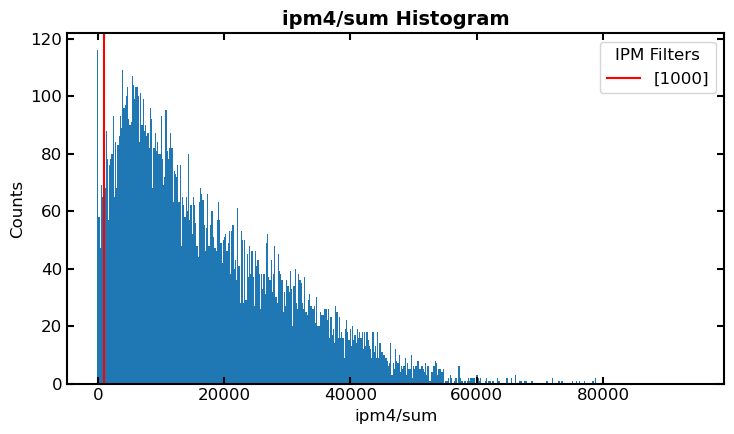

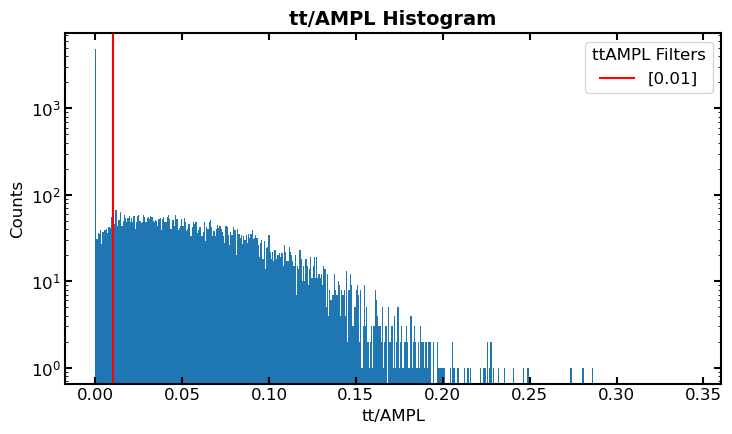

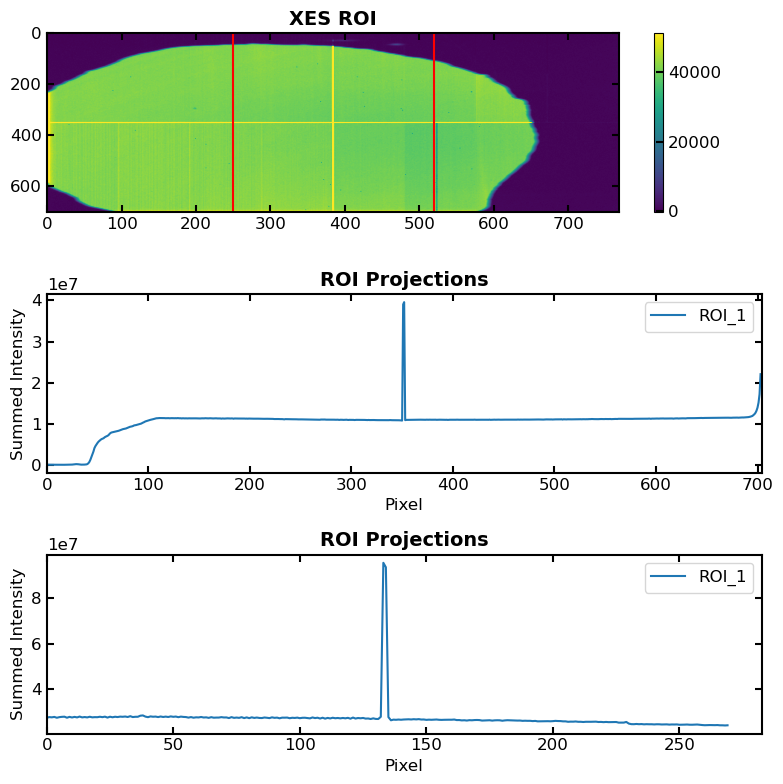

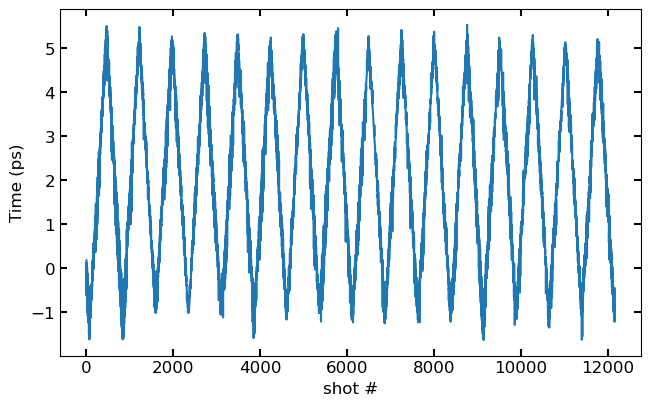

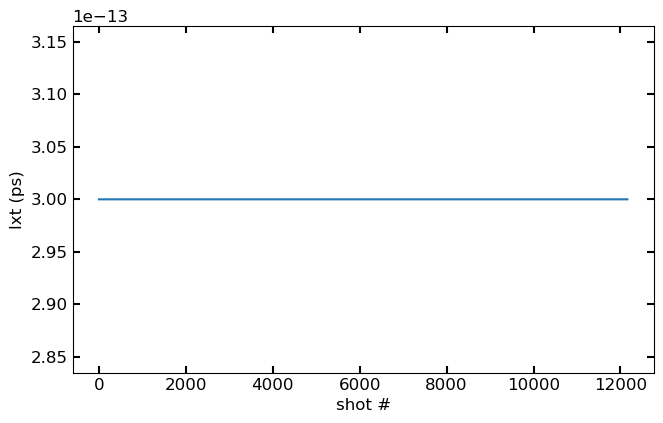

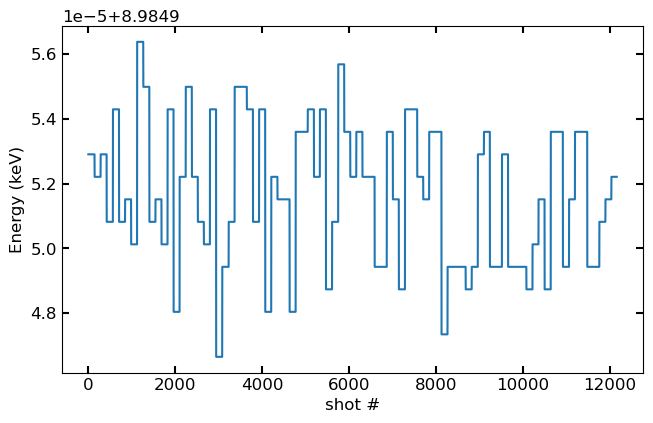

In [5]:
run = 91
exp = 'xcs101572326'
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL', 'epix_2/ROI_area'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt'  ,'encoder','ipm', 'time_tool_ampl', 'epix']

d = dt.diagnostics(run, exp, keys, names)

ipm_thres = [1000]

d.ipm_histogram(ipm_thres)

tt_thres = [0.01]

d.ttAMPL_histogram(tt_thres)

# d.droplet_histogram()

nshots = 1000

# adu_thres = [6]
# d.adu_histogram(nshots, adu_thres)

ka_roi_d = [250, 520]
kb_roi_d = [180, 220]

d.detector_sum_ROI(ka_roi_d)

# d.xas_ROI(nshots, horiz_limits=[10, 360], vert_limits=[20,340])

delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['encoder']][:]

plt.plot(delay)
plt.ylabel('Time (ps)')
# plt.ylim([0, 5])
plt.xlabel('shot #')
plt.show()

plt.plot(d.h5[d.datadict['lxt']][:])
plt.ylabel('lxt (ps)')
# plt.ylim([0, 5])
plt.xlabel('shot #')
plt.show()

plt.plot(d.h5['epicsUser']['dccm_E'][:])
plt.xlabel('shot #')
plt.ylabel('Energy (keV)')
plt.show()

# pdf.close()

## Run 127 ROIsum hist

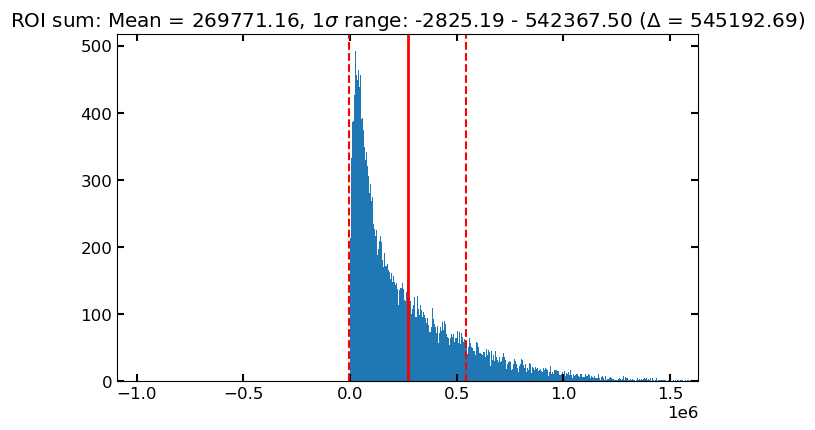

In [37]:
shotmask = (d.h5[d.datadict['ipm']][:] > ipm_thres[0])
data_filt = d.h5['epix_2']['ROI_sum'][shotmask]
data_filt_mean = np.nanmean(data_filt)
data_filt_std = np.nanstd(data_filt)
xmin = np.nanmin(data_filt)
xmax = np.nanmax(data_filt)
binstep = (xmax - xmin)/500

fig, ax = plt.subplots(ncols = 1)

ax.hist(data_filt, bins = np.arange(xmin, xmax, binstep));
# ax.set_xlabel('Delay (ps)')
ax.set_xlim([data_filt_mean - 5*data_filt_std, data_filt_mean + 5*data_filt_std])
ax.axvline(data_filt_mean, color = 'r', linewidth = 2)
ax.axvline(data_filt_mean - data_filt_std, color = 'r', linestyle = '--')
ax.axvline(data_filt_mean + data_filt_std, color = 'r', linestyle = '--')
ax.set_title(r'ROI sum: Mean = %.2f, 1$\sigma$ range: %.2f - %.2f ($\Delta$ = %.2f)' % (data_filt_mean, data_filt_mean - data_filt_std, data_filt_mean + data_filt_std, 2*data_filt_std));

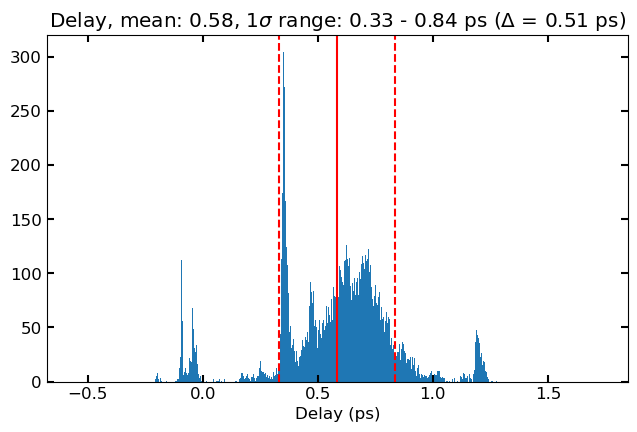

In [38]:
shotmask = (d.h5[d.datadict['ipm']][:] > ipm_thres[0]) & (d.h5[d.datadict['time_tool_ampl']][:] > tt_thres[0]) & (d.h5['tt']['FLTPOSFWHM'][:] < 1000)
# shotmask = (d.h5[d.datadict['time_tool_ampl']][:] > tt_thres[0]) & (d.h5['tt']['FLTPOSFWHM'][:] < 1000)
data_filt = delay[shotmask]
data_filt_mean = np.nanmean(data_filt)
data_filt_std = np.nanstd(data_filt)
xmin = np.nanmin(data_filt)
xmax = np.nanmax(data_filt)
binstep = (xmax - xmin)/500

fig, ax = plt.subplots(ncols = 1)

ax.hist(data_filt, bins = np.arange(xmin, xmax, binstep));
ax.set_xlabel('Delay (ps)')
ax.set_xlim([data_filt_mean - 5*data_filt_std, data_filt_mean + 5*data_filt_std])
ax.axvline(data_filt_mean, color = 'r')
ax.axvline(data_filt_mean - data_filt_std, color = 'r', linestyle = '--')
ax.axvline(data_filt_mean + data_filt_std, color = 'r', linestyle = '--')
ax.set_title(r'Delay, mean: %.2f, 1$\sigma$ range: %.2f - %.2f ps ($\Delta$ = %.2f ps)' % (data_filt_mean, data_filt_mean - data_filt_std, data_filt_mean + data_filt_std, 2*data_filt_std));

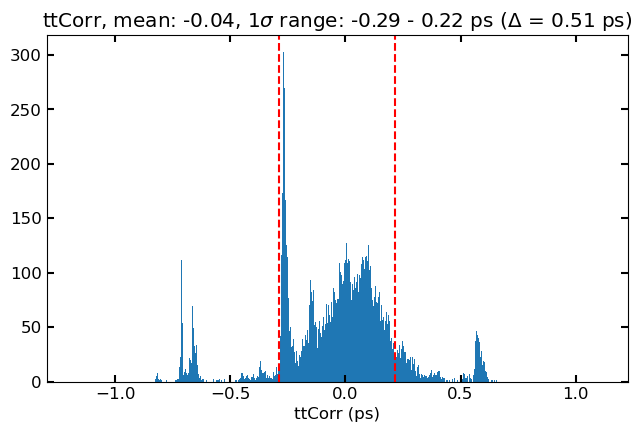

In [39]:
shotmask = (d.h5[d.datadict['ipm']][:] > ipm_thres[0]) & (d.h5[d.datadict['time_tool_ampl']][:] > tt_thres[0]) & (d.h5['tt']['FLTPOSFWHM'][:] < 1000)
data_filt = d.h5['tt']['ttCorr'][shotmask]
data_filt_mean = np.nanmean(data_filt)
data_filt_std = np.nanstd(data_filt)
xmin = np.nanmin(data_filt)
xmax = np.nanmax(data_filt)
binstep = (xmax - xmin)/500

fig, ax = plt.subplots(ncols = 1)

ax.hist(data_filt, bins = np.arange(xmin, xmax, binstep));
ax.set_xlabel('ttCorr (ps)')
ax.set_xlim([data_filt_mean - 5*data_filt_std, data_filt_mean + 5*data_filt_std])
ax.axvline(data_filt_mean - data_filt_std, color = 'r', linestyle = '--')
ax.axvline(data_filt_mean + data_filt_std, color = 'r', linestyle = '--')
ax.set_title(r'ttCorr, mean: %.2f, 1$\sigma$ range: %.2f - %.2f ps ($\Delta$ = %.2f ps)' % (data_filt_mean, data_filt_mean - data_filt_std, data_filt_mean + data_filt_std, 2*data_filt_std));

### XANES 1D Energy

In [42]:
start = time.time()

xspect_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id=exp,lcls_run=exp[-2:])
xes1=XSpect.XSpect_Controller.XASBatchAnalysis_1D_ccm()
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL', 'epix_2/ROI_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt'  ,'encoder','ipm', 'time_tool_ampl', 'epix']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
# xes1.key_epix=['epix_2/ROI_sum']
# xes1.friendly_name_epix=['epix']

##
xes1.set_key_aliases(keys,names)

xes1.add_filter('xray','ipm',ipm_thres[0])
xes1.add_filter('simultaneous','ipm',ipm_thres[0])
xes1.add_filter('simultaneous','time_tool_ampl',tt_thres[0])
xes1.add_filter('simultaneous','time_tool_correction',[-0.05, 0.05])
xes1.scattering = True

xes1.ccm_bins = np.concatenate((np.arange(8.97, 8.975, 0.001), np.arange(8.975, 9.005, 0.0005)))

# xes1.run_parser(['118-125 127 129-135']) # 2 uJ
xes1.run_parser(['270-291']) # 2 uJ

In [43]:
start=time.time()

xes1.primary_analysis_loop(xspect_experiment, verbose = False)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

Analysis completed: 3.02 s


/lscratch/rribson/tmp/ipykernel_253760/2437839838.py:22: RuntimeWarning: invalid value encountered in divide
  xas_lon_norm  = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned
/lscratch/rribson/tmp/ipykernel_253760/2437839838.py:20: RuntimeWarning: invalid value encountered in divide
  xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned


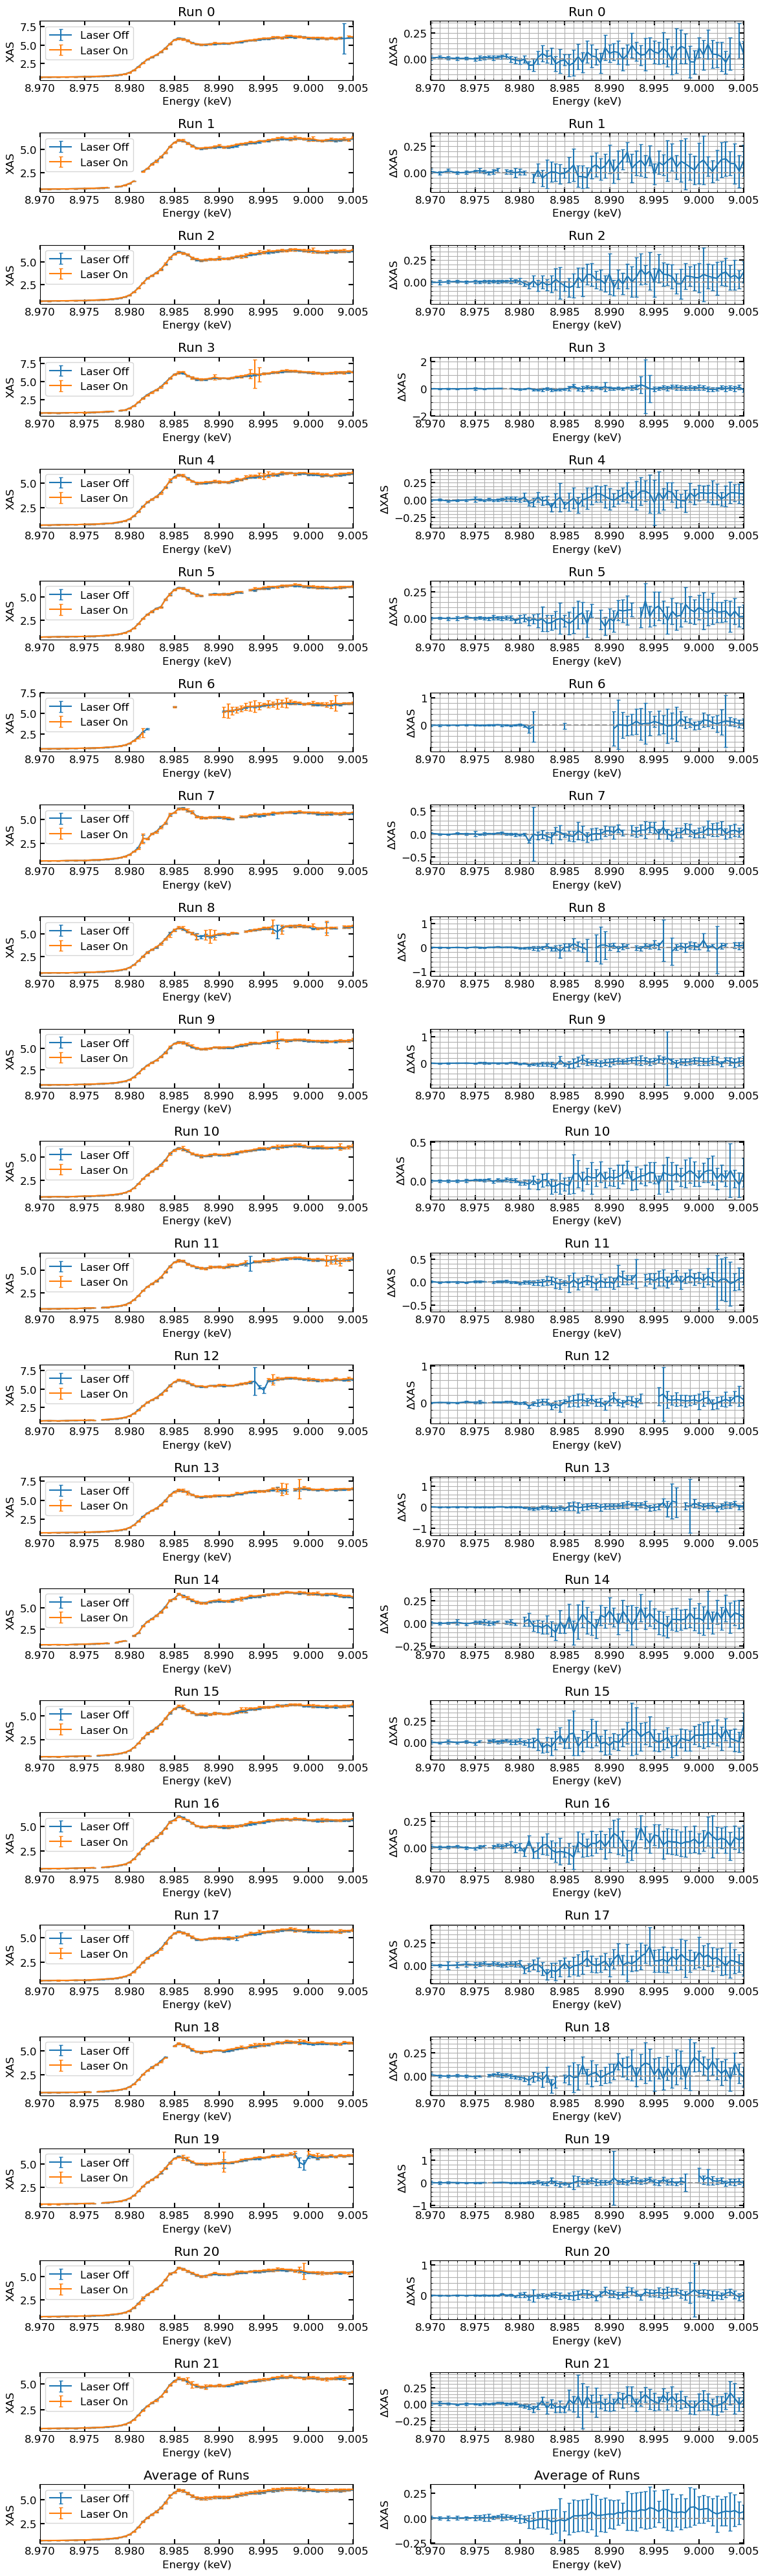

In [50]:
run_count = 0
for ii, run in enumerate(xes1.analyzed_runs):
    # print(ii)
    # print(run.ccm_bins.shape)
    # print(run.epix_simultaneous_laser_energy_binned.shape)
    # print(run.epix_xray_not_laser_energy_binned.shape)
    run_count+=1

fig, ax = plt.subplots(figsize = (12,40), nrows = run_count+1, ncols = 2)

xas_loff_all = []
xas_loff_std_all = []
xas_lon_all  = []
xas_lon_std_all = []
xas_diff_all = []
xas_diff_std_all = []

for ii, run in enumerate(xes1.analyzed_runs):

    xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
    xas_loff_norm_std = np.zeros_like(xas_loff_norm)
    xas_lon_norm  = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned
    xas_lon_norm_std = np.zeros_like(xas_lon_norm)

    for jj in np.arange(xas_loff_norm.shape[0]):
            xas_loff_norm_std[jj] = xas_loff_norm[jj]*np.sqrt( (run.epix_xray_not_laser_std[jj]/run.epix_xray_not_laser_energy_binned[jj])**2 + (run.ipm_xray_not_laser_std[jj]/run.ipm_xray_not_laser_energy_binned[jj])**2)
            xas_lon_norm_std[jj] = xas_lon_norm[jj]*np.sqrt( (run.epix_simultaneous_laser_std[jj]/run.epix_simultaneous_laser_energy_binned[jj])**2 + (run.ipm_simultaneous_laser_std[jj]/run.ipm_simultaneous_laser_energy_binned[jj])**2 )
    xas_diff_norm = np.subtract(xas_lon_norm, xas_loff_norm)
    xas_diff_norm_std = np.sqrt(xas_lon_norm_std**2 + xas_loff_norm_std**2)

    xas_loff_all.append(xas_loff_norm)
    xas_loff_std_all.append(xas_loff_std)
    xas_lon_all.append(xas_lon_norm)
    xas_lon_std_all.append(xas_lon_std)
    xas_diff_all.append(xas_diff_norm)
    xas_diff_std_all.append(xas_diff_norm_std)
    

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    # ax[plt_indx0].plot(run.ccm_bins, xas_loff_norm, label = 'Laser Off')
    # ax[plt_indx0].plot(run.ccm_bins, xas_lon_norm, label = 'Laser On')
    ax[plt_indx0].errorbar(run.ccm_bins, xas_loff_norm, yerr=xas_loff_norm_std, label='Laser Off', capsize=2)
    ax[plt_indx0].errorbar(run.ccm_bins, xas_lon_norm, yerr=xas_lon_norm_std, label='Laser On', capsize=2)
    ax[plt_indx0].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx0].set_xlabel('Energy (keV)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)

    # ax[plt_indx1].plot(run.ccm_bins, xas_diff_norm, label = 'Difference')
    ax[plt_indx1].errorbar(run.ccm_bins, xas_diff_norm, yerr=xas_diff_norm_std, label='Laser Off', capsize=2)
    ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    ax[plt_indx1].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx1].set_xlabel('Energy (keV)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    ax[plt_indx1].minorticks_on()
    ax[plt_indx1].grid(which = 'both')


# ===== Compute mean and SEM =====
xas_loff_all = np.array(xas_loff_all)
xas_loff_std_all = np.array(xas_loff_std_all)
xas_lon_all  = np.array(xas_lon_all)
xas_lon_std_all = np.array(xas_lon_std_all)

N = xas_loff_all.shape[0]
energy_axis = xes1.analyzed_runs[0].ccm_bins

xas_loff_mean = np.nanmean(xas_loff_all, axis=0)
xas_lon_mean  = np.nanmean(xas_lon_all, axis=0)

xas_loff_mean_std = np.sqrt( np.nansum(xas_loff_std_all**2, axis = 0) )
xas_lon_mean_std = np.sqrt( np.nansum(xas_lon_std_all**2, axis = 0) )

# xas_loff_sem = np.nanstd(xas_loff_all, axis=0, ddof=1)/np.sqrt(N)
# xas_lon_sem  = np.nanstd(xas_lon_all, axis=0, ddof=1)/np.sqrt(N)

xas_loff_sem = xas_loff_mean_std/np.sqrt(N)
xas_lon_sem  = xas_lon_mean_std/np.sqrt(N)

xas_diff_mean = xas_lon_mean - xas_loff_mean
xas_diff_sem  = np.sqrt(xas_loff_sem**2 + xas_lon_sem**2)


# ===== Final row with error bars =====
plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].errorbar(energy_axis, xas_loff_mean,
                           yerr=xas_loff_sem,
                           label='Laser Off',
                           capsize=2)

ax[plt_indx0_sum].errorbar(energy_axis, xas_lon_mean,
                           yerr=xas_lon_sem,
                           label='Laser On',
                           capsize=2)

ax[plt_indx0_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Average of Runs')
ax[plt_indx0_sum].axvline(7.1128, color = 'r')


ax[plt_indx1_sum].errorbar(energy_axis, xas_diff_mean,
                           yerr=xas_diff_sem,
                           label='Difference',
                           capsize=2)

ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Average of Runs')
ax[plt_indx1_sum].axvline(11.565, color = 'r')

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Average of Runs')

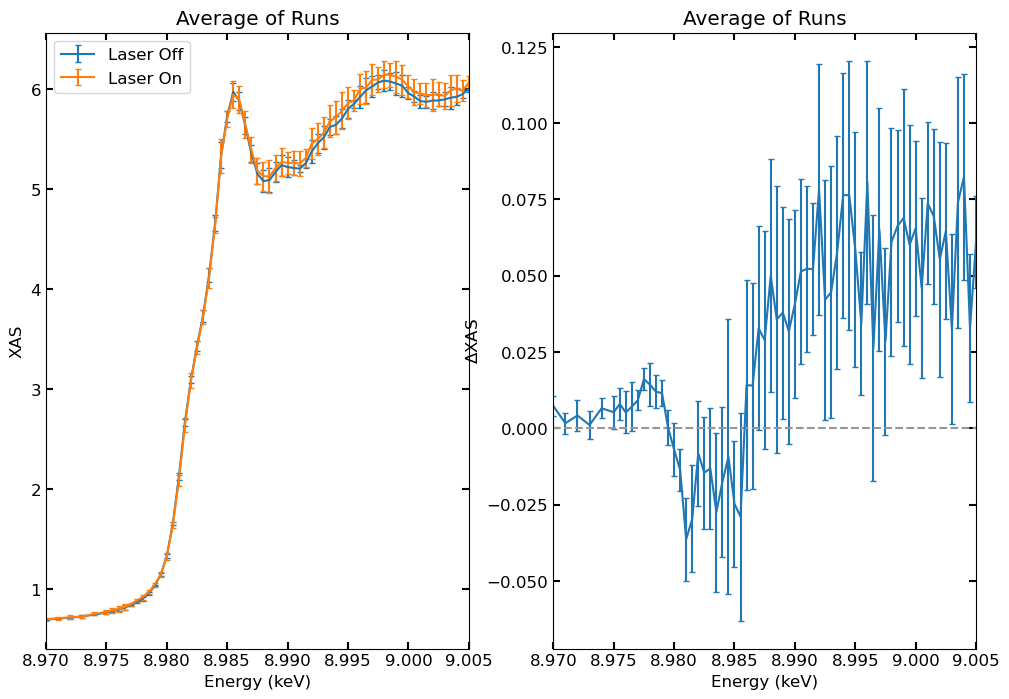

In [59]:
run_count = 0
for ii, run in enumerate(xes1.analyzed_runs):
    # print(ii)
    # print(run.ccm_bins.shape)
    # print(run.epix_simultaneous_laser_energy_binned.shape)
    # print(run.epix_xray_not_laser_energy_binned.shape)
    run_count+=1

# fig, ax = plt.subplots(figsize = (12,40), nrows = run_count+1, ncols = 2)

xas_loff_all = []
xas_loff_std_all = []
xas_loff_bincount_all = []
ipm_loff_all = []
ipm_loff_std_all = []
ipm_loff_bincount_all = []
xas_lon_all  = []
xas_lon_std_all = []
xas_lon_bincount_all = []
ipm_lon_all = []
ipm_lon_std = []
ipm_lon_bincount_all = []

N = len(xes1.analyzed_runs)

xas_loff_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
xas_loff_std_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
xas_loff_bincount_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
ipm_loff_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
ipm_loff_std_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
ipm_loff_bincount_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
xas_lon_all  = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
xas_lon_std_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
xas_lon_bincount_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
ipm_lon_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
ipm_lon_std = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))
ipm_lon_bincount_all = np.zeros((N, xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned.shape[0]))

for ii, run in enumerate(xes1.analyzed_runs):

    # xas_loff_all.append(run.epix_xray_not_laser_energy_binned)
    # xas_loff_bincount_all.append(run.epix_xray_not_laser_bincount)
    # ipm_loff_all.append(run.ipm_xray_not_laser_energy_binned)
    # ipm_loff_bincount_all.append(run.ipm_xray_not_laser_bincount)
    # xas_lon_all.append(run.epix_simultaneous_laser_energy_binned)
    # xas_lon_bincount_all.append(run.epix_simultaneous_laser_bincount)
    # ipm_lon_all.append(run.ipm_simultaneous_laser_energy_binned)
    # ipm_lon_bincount_all.append(run.ipm_simultaneous_laser_bincount)

    xas_loff_all[ii,:] = run.epix_xray_not_laser_energy_binned
    xas_loff_bincount_all[ii,:] = run.epix_xray_not_laser_bincount
    ipm_loff_all[ii,:] = run.ipm_xray_not_laser_energy_binned
    ipm_loff_bincount_all[ii,:] = run.ipm_xray_not_laser_bincount
    xas_lon_all[ii,:] = run.epix_simultaneous_laser_energy_binned
    xas_lon_bincount_all[ii,:] = run.epix_simultaneous_laser_bincount
    ipm_lon_all[ii,:] = run.ipm_simultaneous_laser_energy_binned
    ipm_lon_bincount_all[ii,:] = run.ipm_simultaneous_laser_bincount

# print(xas_loff_all)
# print(xas_loff_bincount_all)

# print(xas_loff_all.shape)
# print(xas_loff_bincount_all.shape)
# xas_loff_all = np.array(xas_loff_all)
# xas_loff_bincount_all = np.array(xas_loff_bincount_all)
# ipm_loff_all = np.array(ipm_loff_all)
# ipm_loff_bincount_all = np.array(ipm_loff_bincount_all)
# xas_lon_all  = np.array(xas_lon_all)
# xas_lon_bincount_all = np.array(xas_lon_bincount_all)
# ipm_lon_all  = np.array(ipm_lon_all)
# ipm_lon_bincount_all = np.array(ipm_lon_bincount_all)

# N = xas_loff_all.shape[0]
energy_axis = xes1.analyzed_runs[0].ccm_bins

xas_loff_sum = np.nansum(xas_loff_all, axis = 0)
xas_loff_sum_std = np.nanstd(xas_loff_all, axis = 0)
xas_loff_bincount_sum = np.nansum(xas_loff_bincount_all, axis = 0)

ipm_loff_sum = np.nansum(ipm_loff_all, axis = 0)
ipm_loff_sum_std = np.nanstd(ipm_loff_all, axis = 0)
ipm_loff_bincount_sum = np.nansum(ipm_loff_bincount_all, axis = 0)

xas_lon_sum = np.nansum(xas_lon_all, axis = 0)
xas_lon_sum_std = np.nanstd(xas_lon_all, axis = 0)
xas_lon_bincount_sum = np.nansum(xas_lon_bincount_all, axis = 0)

ipm_lon_sum = np.nansum(ipm_lon_all, axis = 0)
ipm_lon_sum_std = np.nanstd(ipm_lon_all, axis = 0)
ipm_lon_bincount_sum = np.nansum(ipm_lon_bincount_all, axis = 0)

xas_loff = xas_loff_sum/ipm_loff_sum
xas_lon = xas_lon_sum/ipm_lon_sum
xas_diff = np.subtract(xas_lon, xas_loff)

xas_loff_std = np.zeros_like(xas_loff)
xas_lon_std = np.zeros_like(xas_lon)

for jj in np.arange(xas_loff.shape[0]):
    xas_loff_std[jj] = xas_loff[jj]*np.sqrt( (xas_loff_sum_std[jj]/xas_loff_sum[jj])**2 + (ipm_loff_sum_std[jj]/ipm_loff_sum[jj])**2)
    xas_lon_std[jj] = xas_lon[jj]*np.sqrt( (xas_lon_sum_std[jj]/xas_lon_sum[jj])**2 + (ipm_lon_sum_std[jj]/ipm_lon_sum[jj])**2 )

xas_diff_std = np.sqrt(xas_lon_std**2 + xas_loff_std**2)
xas_diff_sem = xas_diff_std/np.sqrt(N)

###

fig, ax = plt.subplots(figsize = (12,8), nrows = 1, ncols = 2)

plt_indx0_sum = (0,)
plt_indx1_sum = (1,)

ax[plt_indx0_sum].errorbar(energy_axis, xas_loff,
                           yerr=xas_loff_std,
                           label='Laser Off',
                           capsize=2)

ax[plt_indx0_sum].errorbar(energy_axis, xas_lon,
                           yerr=xas_lon_std,
                           label='Laser On',
                           capsize=2)

ax[plt_indx0_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Average of Runs')
# ax[plt_indx0_sum].axvline(eline, color = 'r', linestyle = '--')
# ax[plt_indx0_sum].set_xlim(enlimits)



ax[plt_indx1_sum].errorbar(energy_axis, xas_diff,
                           yerr=xas_diff_sem,
                           label='Difference',
                           capsize=2)

ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Average of Runs')

Text(0.5, 1.0, 'Average of Runs')

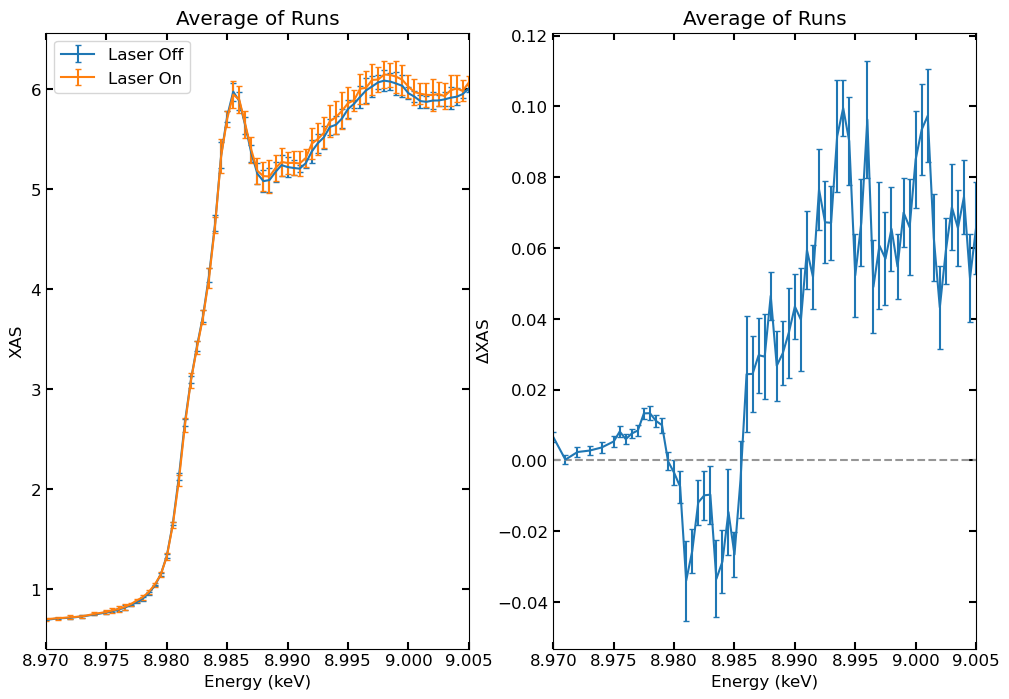

In [56]:
xas_diff_all = np.array(xas_diff_all)
xas_diff_std_all = np.array(xas_diff_std_all)

xas_diff_all_mean = np.nanmean(xas_diff_all, axis = 0)
xas_diff_std2 = np.nanstd(xas_diff_all, axis = 0, ddof = 0)

xas_diff_sem2 = xas_diff_std2/np.sqrt(N)

###

fig, ax = plt.subplots(figsize = (12,8), nrows = 1, ncols = 2)

plt_indx0_sum = (0,)
plt_indx1_sum = (1,)

ax[plt_indx0_sum].errorbar(energy_axis, xas_loff,
                           yerr=xas_loff_std,
                           label='Laser Off',
                           capsize=2)

ax[plt_indx0_sum].errorbar(energy_axis, xas_lon,
                           yerr=xas_lon_std,
                           label='Laser On',
                           capsize=2)

ax[plt_indx0_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Average of Runs')
# ax[plt_indx0_sum].axvline(eline, color = 'r', linestyle = '--')
# ax[plt_indx0_sum].set_xlim(enlimits)

ax[plt_indx1_sum].errorbar(energy_axis, xas_diff_all_mean,
                           yerr=xas_diff_sem2,
                           label='Difference',
                           capsize=2)

ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Average of Runs')

Text(0.5, 1.0, 'Average of Runs')

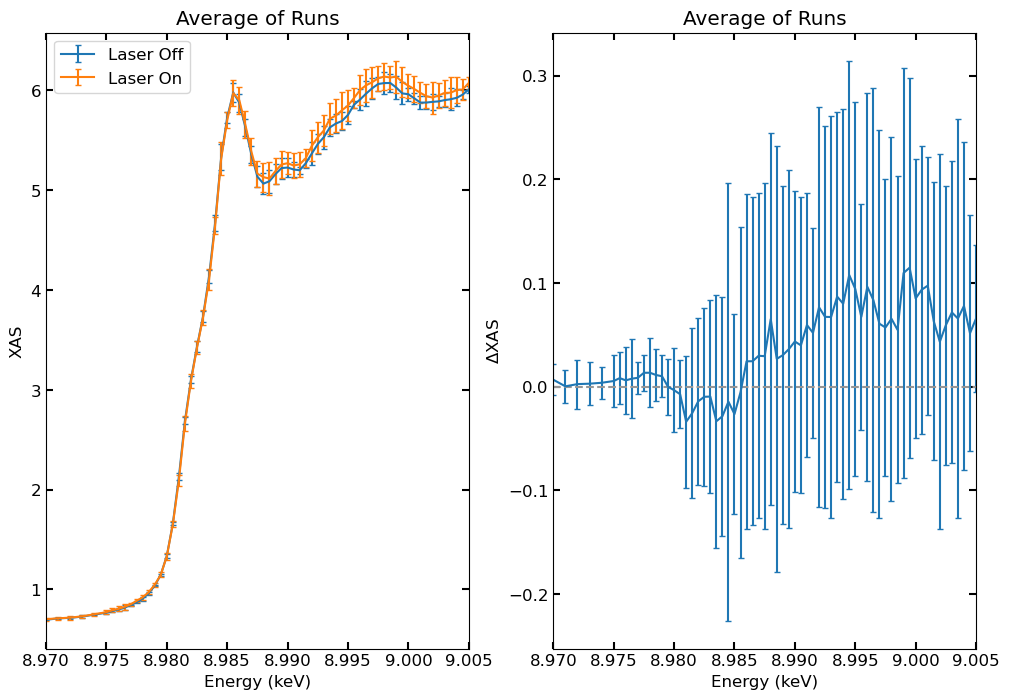

In [49]:
fig, ax = plt.subplots(figsize = (12,8), nrows = 1, ncols = 2)

# eline = 11.5663
# enlimits = [11.555, 11.58]

plt_indx0_sum = (0,)
plt_indx1_sum = (1,)

ax[plt_indx0_sum].errorbar(energy_axis, xas_loff_mean,
                           yerr=xas_loff_sem,
                           label='Laser Off',
                           capsize=2)

ax[plt_indx0_sum].errorbar(energy_axis, xas_lon_mean,
                           yerr=xas_lon_sem,
                           label='Laser On',
                           capsize=2)

ax[plt_indx0_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Average of Runs')
# ax[plt_indx0_sum].axvline(eline, color = 'r', linestyle = '--')
# ax[plt_indx0_sum].set_xlim(enlimits)



ax[plt_indx1_sum].errorbar(energy_axis, xas_diff_mean,
                           yerr=xas_diff_sem,
                           label='Difference',
                           capsize=2)

ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Average of Runs')
# ax[plt_indx1_sum].axvline(eline, color = 'r', linestyle = '--')
# ax[plt_indx1_sum].set_xlim(enlimits)